In [2]:
import xarray as xr 
import glob
import torch 
import matplotlib.pyplot as plt
import numpy as np
import cartopy 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
import numpy as np

def leading_eof1(X):
    # Remove time mean
    X_anom = X - np.mean(X, axis=0, keepdims=True)

    # Covariance in vertical/space dimension
    C = np.cov(X_anom, rowvar=False)

    # Eigen-decomposition
    eigvals, eigvecs = np.linalg.eigh(C)

    # Sort descending
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # Leading EOF and PC
    eof1 = eigvecs[:, 0]
    pc1 = X_anom @ eof1

    return eof1, pc1, eigvals[0] / np.sum(eigvals)

def leading_eof2(X):
    # Remove time mean
    X_anom = X - np.mean(X, axis=0, keepdims=True)

    # Covariance in vertical/space dimension
    C = np.cov(X_anom, rowvar=False)

    # Eigen-decomposition
    eigvals, eigvecs = np.linalg.eigh(C)

    # Sort descending
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # Leading EOF and PC
    eof2 = eigvecs[:, 1]
    pc2 = X_anom @ eof2

    return eof2, pc2, eigvals[0] / np.sum(eigvals)

In [3]:
DS = xr.open_dataset('/glade/work/wchapman/b.e21.BHIST.f09_g17_Seasonal_Stochai_b050_025_1980.cam.h1.2010-10-13-00000.nc') 
lat = DS["lat"].values if hasattr(DS["lat"], "values") else DS["lat"]
lon = DS["lon"].values if hasattr(DS["lon"], "values") else DS["lon"]
lev = DS["lev"].values

dir_o = "/glade/derecho/scratch/kjmayer/CUVACAR_xai/IG/"
# IG lat, lon, level, and dates of interest
lat_of_interest = 25 #N
lon_of_interest = 60 #E
lev_of_interest = 500 #hPa
idatesstrt, idateend = 0, 30 # = January

# Find associated index value for getting data
lat_of_interest_near = DS["lat"].sel(lat=lat_of_interest, method='nearest')
lon_of_interest_near = DS["lon"].sel(lon=lon_of_interest, method='nearest')
lev_of_interest_near = DS["lev"].sel(lev=lev_of_interest, method='nearest')

ilat_of_interest = np.where(lat == lat_of_interest_near.values)[0][0]
ilon_of_interest = np.where(lon == lon_of_interest_near.values)[0][0]
ilev_of_interest = np.where(lev == lev_of_interest_near.values)[0][0]

ilat_of_interest_str = f"{ilat_of_interest:05}"
ilon_of_interest_str = f"{ilon_of_interest:05}"
ilev_of_interest_str = f"{ilev_of_interest:05}"

# grab all dates for the same level, lat, and lon point
files = sorted(
    glob.glob(dir_o+"*/tensor_steps24_parrallel_lev"+ilev_of_interest_str+"_lat"+ilat_of_interest_str+"_lon"+ilon_of_interest_str+".npy")
)[idatesstrt:idateend]
stackeddate = np.stack([np.load(f).squeeze() for f in files])

# Specify which variable EOF you want to look at:
addval = 64
# Notes for addval:
# U = input_tensor[0:32] # 0
# V = input_tensor[32:64] # 32
# T = input_tensor[64:96] # 64
# Q = input_tensor[96:128] # 96
# TREFHT = input_tensor[129]
# PS = input_tensor[128]
# co2mr_3d = input_tensor[-1]
# ICEFRAC = input_tensor[-2]
# SST = input_tensor[-3]
# SOLIN = input_tensor[-4]
# LANDM_COSLAT = input_tensor[-5]
# z_norm = input_tensor[-6]

### EOF Analysis across level, latitude, and longitude

In [4]:
# Preprocess Data for 3D EOF
delta_lat = float((DS["lat"][1] - DS["lat"][0]).values)
delta_lon = float((DS["lon"][1] - DS["lon"][0]).values)

# grab +/- location of interet for horizontal portion of EOF
lat_range_of_interest = 5 #N +/-
lon_range_of_interest = 15 #E +/-

south_lat_of_interest = int(ilat_of_interest-(lat_range_of_interest/delta_lat))
north_lat_of_interest = int(ilat_of_interest+(lat_range_of_interest/delta_lat))

west_lon_of_interest = int(ilon_of_interest-(lon_range_of_interest/delta_lon))
east_lon_of_interest = int(ilon_of_interest+(lon_range_of_interest/delta_lon))

time_space_matrix_temp = stackeddate[:, 0+addval:32+addval, south_lat_of_interest:north_lat_of_interest, west_lon_of_interest:east_lon_of_interest]

time_space_matrix = np.reshape(time_space_matrix_temp,
                               (time_space_matrix_temp.shape[0],
                                time_space_matrix_temp.shape[1]*time_space_matrix_temp.shape[2]*time_space_matrix_temp.shape[3])
                               )

In [5]:
X = time_space_matrix.copy()

eof1, pc1, eigvals = leading_eof1(X)

print("Leading eigenvalue fraction:")
print(eigvals)

print("Leading eigenvector:")
print(eof1)

eof1_reshape = np.reshape(eof1,
                          (time_space_matrix_temp.shape[1],
                           time_space_matrix_temp.shape[2],
                           time_space_matrix_temp.shape[3]))

Leading eigenvalue fraction:
0.4416525590738568
Leading eigenvector:
[ 1.18456490e-05  1.12503001e-05  1.35960749e-05 ...  5.02544809e-05
  4.58111072e-06 -7.14367945e-06]


/glade/derecho/scratch/kjmayer/tmp/ipykernel_1899/2765379796.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


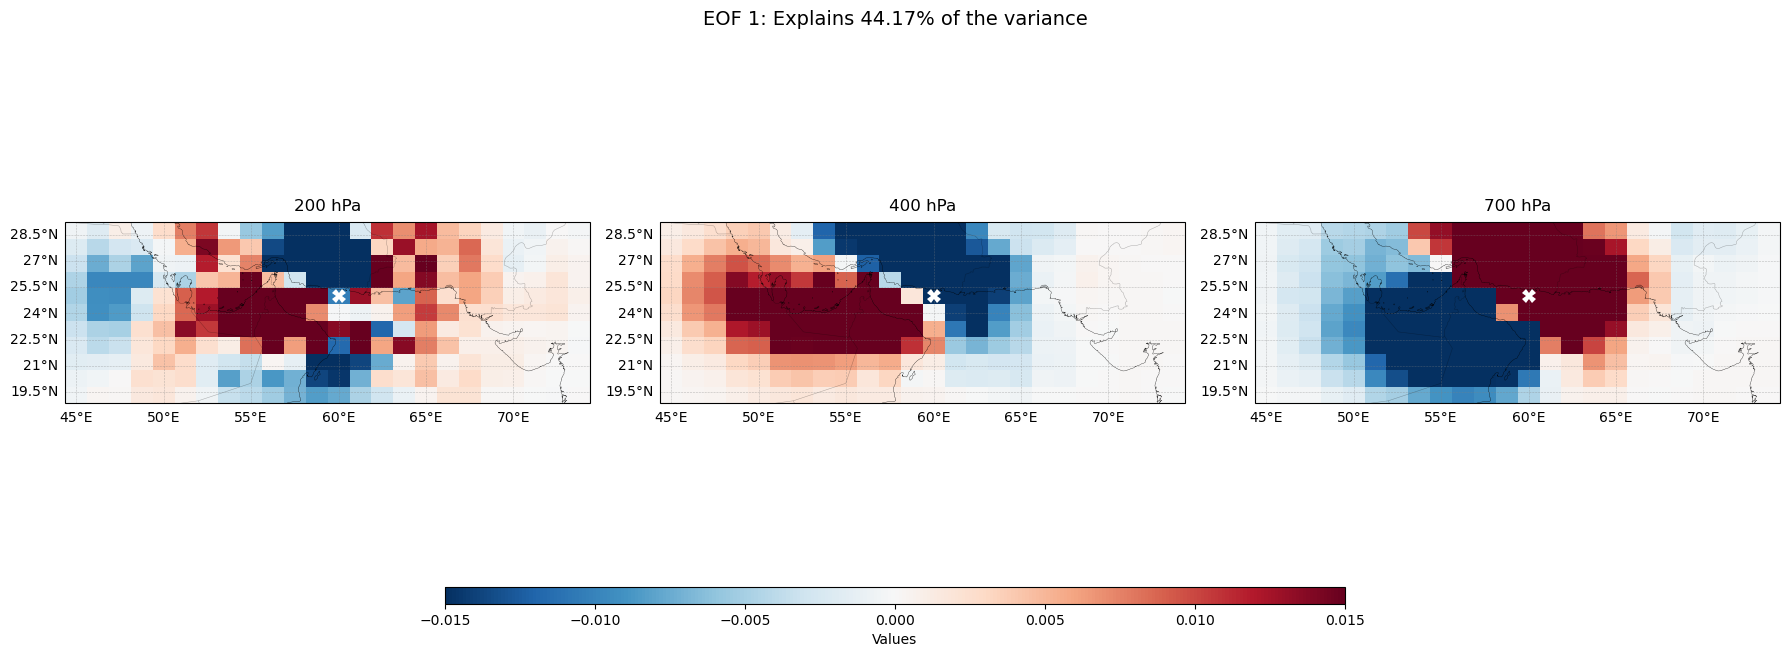

In [6]:
levels_of_interest = [200, 400, 700]

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5.5),
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=180)},
)

vmin = -1.5e-2
vmax = 1.5e-2
vdot_lat = lat[ilat_of_interest]
vdot_lon = lon[ilon_of_interest]

for ax, level_of_interest in zip(axes, levels_of_interest):
    lev_of_interest_near = DS["lev"].sel(lev=level_of_interest, method='nearest')
    ilev_of_interest = np.where(DS["lev"].values == lev_of_interest_near.values)[0][0]

    im = ax.pcolormesh(
        lon[west_lon_of_interest:east_lon_of_interest],
        lat[south_lat_of_interest:north_lat_of_interest],
        eof1_reshape[ilev_of_interest],
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        shading="auto",
    )

    ax.plot(
        vdot_lon,
        vdot_lat,
        marker="X",
        markersize=10,
        markerfacecolor="white",
        markeredgecolor="white",
        markeredgewidth=0,
        transform=ccrs.PlateCarree(),
        zorder=10,
    )

    ax.coastlines(linewidth=0.22)
    ax.add_feature(cfeature.BORDERS, linewidth=0.35, alpha=0.3)

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.4,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )
    gl.top_labels = False
    gl.right_labels = False

    ax.set_title(f"{level_of_interest} hPa", fontsize=12, pad=8)

cbar_ax = fig.add_axes([0.25, -0.06, 0.5, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Values")

fig.suptitle(
    "EOF 1: Explains " + str((eigvals * 100).round(2)) + "% of the variance",
    fontsize=14,
    y=1.02,
)

plt.tight_layout()
plt.show()

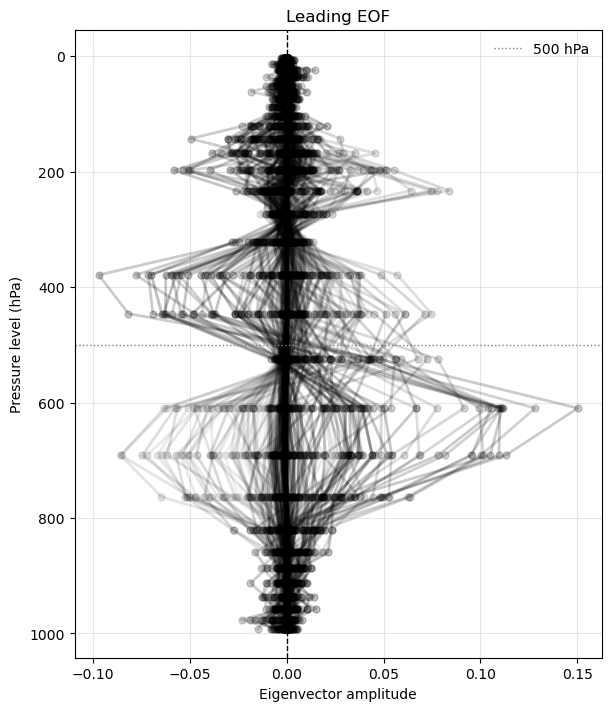

In [7]:
# Plot both on the same axes
fig, ax = plt.subplots(figsize=(6, 7), constrained_layout=True)
alpha = 0.001
for vlat in range(eof1_reshape.shape[1]):
    for vlon in range(eof1_reshape.shape[2]):
        ax.plot(
            eof1_reshape[:,vlat,vlon],
            lev,
            marker="o",
            linewidth=2,
            markersize=5,
            color='k',
            alpha=alpha
            # label=f"EOF 1"
        )
        alpha += 0.001

ax.axvline(
    x=0,
    color="k",
    linestyle="--",
    linewidth=1
)

ax.axhline(
    y=500,
    color="gray",
    linestyle=":",
    linewidth=1,
    label="500 hPa"
)

ax.invert_yaxis()
ax.set_xlabel("Eigenvector amplitude")
ax.set_ylabel("Pressure level (hPa)")
ax.set_title("Leading EOF")
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)

plt.show()

### Example of IG for one date and all locations at one vertical level

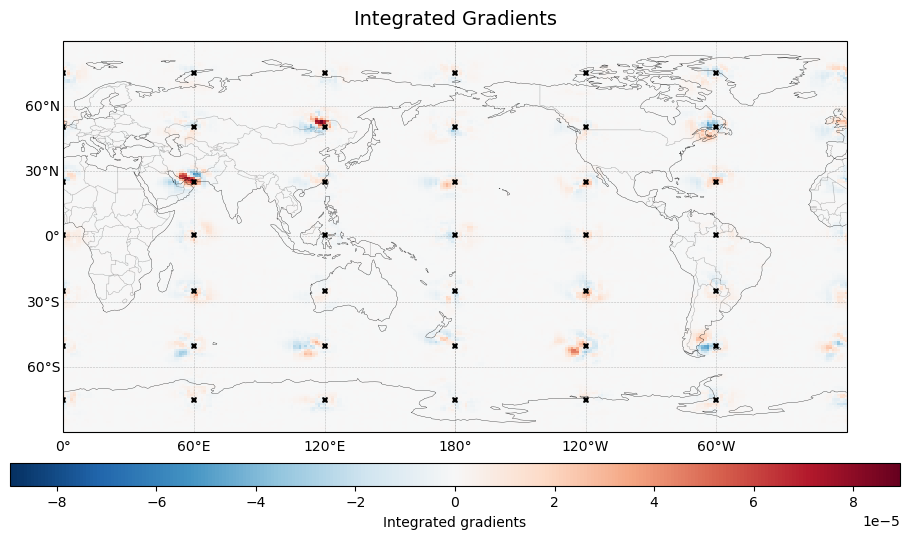

In [8]:
# Example of IG for one date and all locations at one vertical level
DATE = '1981-01-15'
dir_o = "/glade/derecho/scratch/kjmayer/CUVACAR_xai/IG/"+DATE+"/"
files = sorted(glob.glob(dir_o+"tensor_steps24_parrallel_lev00020_lat*.npy"))
stacked = np.stack([np.load(f).squeeze()[20+32+32-4].squeeze() for f in files])

mean_IG = np.mean(stacked, axis=0)

field_cyc, lon_cyc = add_cyclic_point(mean_IG, coord=lon)

vmax = np.nanmax(np.abs(field_cyc))
vmin = -vmax

fig = plt.figure(figsize=(12, 5.5))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

im = ax.pcolormesh(
    lon_cyc,
    lat,
    field_cyc,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    shading="auto",
)

lat_idx = [16, 42, 69, 96, 122, 149, 175]
lon_idx = [0, 48, 96, 144, 192, 240]

dot_lat = lat[lat_idx]
dot_lon = lon_cyc[lon_idx]

for vdot_lat in dot_lat:
    for vdot_lon in dot_lon:
        ax.plot(
            vdot_lon,
            vdot_lat,
            marker="X",
            markersize=5,
            markerfacecolor="black",
            markeredgecolor="black",
            markeredgewidth=0,
            transform=ccrs.PlateCarree(),
            zorder=10,
        )

ax.set_global()
ax.coastlines(linewidth=0.22)
ax.add_feature(cfeature.BORDERS, linewidth=0.35, alpha=0.3)
# ax.add_feature(cfeature.LAND, facecolor="0.85", alpha=0.35)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.5,
    linestyle="--",
)
gl.top_labels = False
gl.right_labels = False

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.07,
    fraction=0.05,
    aspect=40,
)
cbar.set_label("Integrated gradients")

ax.set_title("Integrated Gradients", fontsize=14, pad=12)

plt.tight_layout()
plt.show()